# Figure with Stan model fits to Busulfan chimera data

A model output visualization notebook for the adult MZ B cell analysis, comparing experimental measurements to fitted model predictions across age-at-BMT groups.


In [ ]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats
from matplotlib.lines import Line2D

In [178]:
# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica Neue"]  # prefer Helvetica, fallback if unavailable

In [179]:
#Change the working directory
import os
os.chdir('/Users/apoorvasingh/Desktop/MZB-new-analysis')

In [180]:
#open the output file

import os

file_path = 'data/New output (pkl)/Steady State/TDM/TDM_influx_T1.pkl'
with open(file_path, 'rb') as f:
    SHM_T1 = pkl.load(f)

file_path = 'data/New output (pkl)/Steady State/TDM/TDM_influx_T2.pkl'
with open(file_path, 'rb') as f:
    SHM_T2 = pkl.load(f)
    
file_path = 'data/New output (pkl)/Steady State/TDM/TDM_influx_FO.pkl'
with open(file_path, 'rb') as f:
    SHM_FO= pkl.load(f)

file_path = 'data/New output (pkl)/Steady State/TDM/TDM_influx_T2MZP.pkl'
with open(file_path, 'rb') as f:
    SHM_T2MZP= pkl.load(f)




In [181]:
# open experimental data file 
df = pd.read_csv('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/new_data_MZB.csv')
df = df.sort_values(by='Age at S1K')
print(df)


                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [182]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df['agebin'] = pd.cut(df['Age at BMT'], bins=[0,70, 140], labels=['≤10 weeks', '>10 weeks'])
print(df)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [183]:
my_pal = ['#FAA51A','#2e2976']

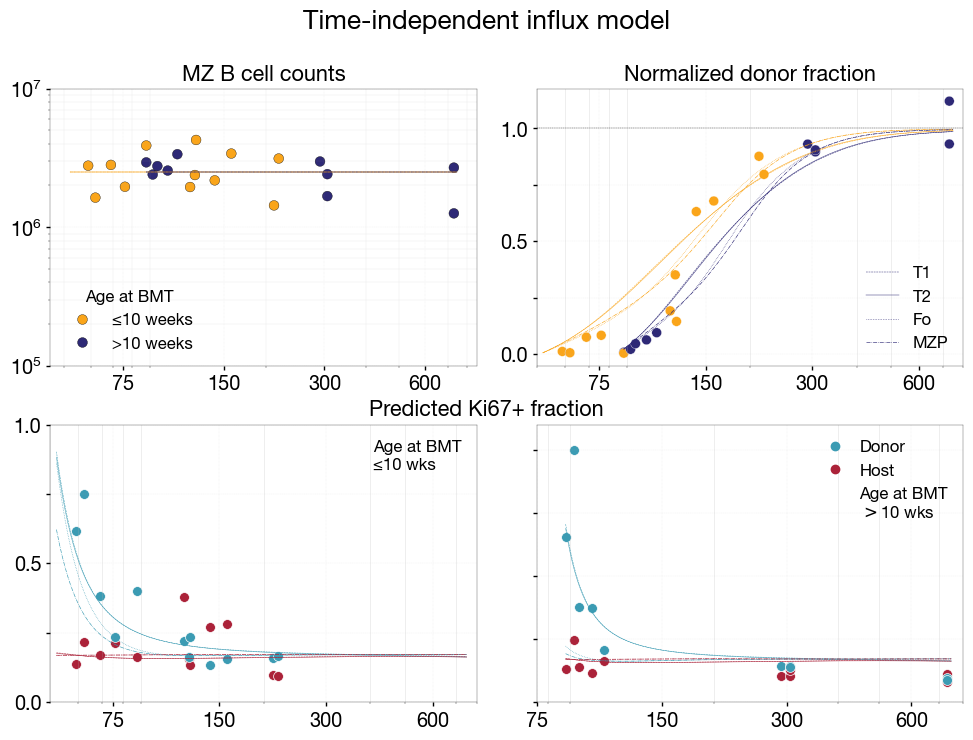

In [184]:
sns.set_context("notebook", font_scale=1.3)

ts1= np.arange(52, 750, 1)
ts2= np.arange(88, 750, 1)
ts3= np.arange(291, 750, 1)

# Plotting
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 6)  # Create a GridSpec with 2 rows and 4 columns

# Create the subplots
ax1 = fig.add_subplot(gs[0, 0:3])  # First row, spanning columns 0 to 1
ax2 = fig.add_subplot(gs[0, 3:6])  # First row, spanning columns 2 to 3
# second row has 3 plots based on the age at BMT
ax_3 = fig.add_subplot(gs[1, 0:3])  # First row, spanning columns 0 to 1
ax_4 = fig.add_subplot(gs[1, 3:6])  # First row, spanning columns 2 to 3
text_only_handle = Line2D([], [], linestyle='none')
# Common title for the whole figure
fig.suptitle('Time-independent influx model', fontweight='bold', fontsize=19, y=0.93)
# Common title for the bottom row (ax_3 and ax_4)
fig.text(0.5, 0.43, 'Predicted Ki67+ fraction', ha='center', va='center')


# Plot total MZ cell counts
# sns.scatterplot(ax=ax1, data=df, x='Age at S1K', y='total_MZ', alpha=0.85, hue ='agebin', s=100, legend=False, palette=my_pal)
sns.scatterplot(ax= ax1, data=df, x='Age at S1K', y='total_MZ', hue='agebin', palette= my_pal, s=50, edgecolor='black',linewidth=0.25)

ax1.plot(ts1, np.mean(SHM_T1.MZ_counts_pred1, axis=0), color = my_pal[0], linestyle='dashed',linewidth=0.25)
ax1.plot(ts2, np.mean(SHM_T1.MZ_counts_pred2, axis=0), color = my_pal[1], linestyle='dashed',linewidth=0.25)
ax1.plot(ts1, np.mean(SHM_T2.MZ_counts_pred1, axis=0), color = my_pal[0],  linewidth=0.25)
ax1.plot(ts2, np.mean(SHM_T2.MZ_counts_pred2, axis=0), color = my_pal[1],  linewidth=0.25)
ax1.plot(ts1, np.mean(SHM_FO.MZ_counts_pred1, axis=0), color = my_pal[0], linestyle='dotted', linewidth=0.25)
ax1.plot(ts2, np.mean(SHM_FO.MZ_counts_pred2, axis=0), color = my_pal[1], linestyle='dotted', linewidth=0.25)
ax1.plot(ts1, np.mean(SHM_T2MZP.MZ_counts_pred1, axis=0), color = my_pal[0], linestyle='dashdot', linewidth=0.25)
ax1.plot(ts2, np.mean(SHM_T2MZP.MZ_counts_pred2, axis=0), color = my_pal[1], linestyle='dashdot', linewidth=0.25)

# ax1.fill_between(ts1, np.quantile(SHM_T1.MZ_counts_pred1, 0.025, axis=0), np.quantile(SHM_T1.MZ_counts_pred1, 0.975, axis=0), alpha=0.05, color = my_pal[0])
# ax1.fill_between(ts2, np.quantile(SHM_T1.MZ_counts_pred2, 0.025, axis=0), np.quantile(SHM_T1.MZ_counts_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])           
# ax1.fill_between(ts1, np.quantile(SHM_T2.MZ_counts_pred1, 0.025, axis=0), np.quantile(SHM_T2.MZ_counts_pred1, 0.975, axis=0), alpha=0.05, color = my_pal[0])
# ax1.fill_between(ts2, np.quantile(SHM_T2.MZ_counts_pred2, 0.025, axis=0), np.quantile(SHM_T2.MZ_counts_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])  
# ax1.fill_between(ts1, np.quantile(SHM_FO.MZ_counts_pred1, 0.025, axis=0), np.quantile(SHM_FO.MZ_counts_pred1, 0.975, axis=0), alpha=0.05, color = my_pal[0])
# ax1.fill_between(ts2, np.quantile(SHM_FO.MZ_counts_pred2, 0.025, axis=0), np.quantile(SHM_FO.MZ_counts_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])  
# ax1.fill_between(ts1, np.quantile(SHM_T2MZP.MZ_counts_pred1, 0.025, axis=0), np.quantile(SHM_T2MZP.MZ_counts_pred1, 0.975, axis=0), alpha=0.05, color = my_pal[0])
# ax1.fill_between(ts2, np.quantile(SHM_T2MZP.MZ_counts_pred2, 0.025, axis=0), np.quantile(SHM_T2MZP.MZ_counts_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])  
ax1.set_ylim(1e5, 1e7)
ax1.set_yscale('log')  # sets the y-axis to a logarithmic scale
ax1.set_xscale('log')
ax1.set_xticks([75, 150, 300, 600])
ax1.set_xticklabels([75, 150, 300, 600])
ax1.set_ylabel('')
ax1.tick_params(axis='both')
ax1.set_xlabel('')
ax1.set_title('MZ B cell counts')
ax1.grid(True, which='both', ls="solid", linewidth=0.25, alpha=0.3)
ax1.legend(title='Age at BMT', frameon=False, fontsize=12, title_fontsize=12)
# no legend for points



# Plot normalized donor fraction
sns.scatterplot(ax=ax2, data=df, x='Age at S1K', y='Nfd_MZ', hue='agebin', s=50, legend= False, linewidth=0.25, palette=my_pal)
ax2.plot(ts1, np.mean(SHM_T1.Nfd_pred1, axis=0), color=my_pal[0], linewidth=0.35, linestyle='dashed')
ax2.plot(ts2, np.mean(SHM_T1.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dashed', linewidth=0.35, label='T1')
ax2.plot(ts1, np.mean(SHM_T2.Nfd_pred1, axis=0), color=my_pal[0],  linewidth=0.35)
ax2.plot(ts2, np.mean(SHM_T2.Nfd_pred2, axis=0), color=my_pal[1],  linewidth=0.35, label='T2')
ax2.plot(ts1, np.mean(SHM_FO.Nfd_pred1, axis=0), color=my_pal[0], linestyle='dotted', linewidth=0.45)
ax2.plot(ts2, np.mean(SHM_FO.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dotted', linewidth=0.45, label='Fo')
ax2.plot(ts1, np.mean(SHM_T2MZP.Nfd_pred1, axis=0), color=my_pal[0], linestyle='dashdot', linewidth=0.45)
ax2.plot(ts2, np.mean(SHM_T2MZP.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dashdot', linewidth=0.45, label='MZP')
# ax2.fill_between(ts1, np.quantile(SHM_T1.Nfd_pred1, 0.025, axis=0), np.quantile(SHM_T1.Nfd_pred1, 0.975, axis=0), alpha=0.05, color= my_pal[0])
# ax2.fill_between(ts2, np.quantile(SHM_T1.Nfd_pred2, 0.025, axis=0), np.quantile(SHM_T1.Nfd_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])
# ax2.fill_between(ts1, np.quantile(SHM_T2.Nfd_pred1, 0.025, axis=0), np.quantile(SHM_T2.Nfd_pred1, 0.975, axis=0), alpha=0.05, color= my_pal[0])
# ax2.fill_between(ts2, np.quantile(SHM_T2.Nfd_pred2, 0.025, axis=0), np.quantile(SHM_T2.Nfd_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])
# ax2.fill_between(ts1, np.quantile(SHM_FO.Nfd_pred1, 0.025, axis=0), np.quantile(SHM_FO.Nfd_pred1, 0.975, axis=0), alpha=0.05, color= my_pal[0])
# ax2.fill_between(ts2, np.quantile(SHM_FO.Nfd_pred2, 0.025, axis=0), np.quantile(SHM_FO.Nfd_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])
# ax2.fill_between(ts1, np.quantile(SHM_T2MZP.Nfd_pred1, 0.025, axis=0), np.quantile(SHM_T2MZP.Nfd_pred1, 0.975, axis=0), alpha=0.05, color= my_pal[0])
# ax2.fill_between(ts2, np.quantile(SHM_T2MZP.Nfd_pred2, 0.025, axis=0), np.quantile(SHM_T2MZP.Nfd_pred2, 0.975, axis=0), alpha=0.05, color = my_pal[1])
ax2.set_xlim(50, 800)
ax2.set_xscale('log')
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_yticklabels(['0.0', '', '0.5', '', '1.0'])
ax2.set_xlabel('')
ax2.set_title('Normalized donor fraction')
ax2.axhline(y=1, color='black', linestyle='dashed', linewidth=0.25)
ax2.legend(frameon=False, fontsize=12, title_fontsize=12)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)      

#Construct a new dataframe for agebin1, agebin2 and agebin3
df_Ki67_bin1 = df[df['agebin'] == '≤10 weeks']
df_Ki67_bin2 = df[df['agebin'] == '>10 weeks']


# Plot Proportion of Ki67+ MZ cells for age bin1
sns.scatterplot(ax=ax_3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host', s=50, linewidth=0.5, color='#ab2239')
sns.scatterplot(ax=ax_3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', s=50, linewidth=0.5, color='#3b9bb3')
ax_3.plot(ts1, np.mean(SHM_T1.donor_ki_pred1, axis=0), color= '#3b9bb3',linestyle='dashed', linewidth=0.35)
ax_3.plot(ts1, np.mean(SHM_T2.donor_ki_pred1, axis=0), color= '#3b9bb3', linewidth=0.35)
ax_3.plot(ts1, np.mean(SHM_FO.donor_ki_pred1, axis=0), color= '#3b9bb3', linewidth=0.45, linestyle='dotted')
ax_3.plot(ts1, np.mean(SHM_T2MZP.donor_ki_pred1, axis=0), color= '#3b9bb3', linewidth=0.45, linestyle='dashdot')
# ax_3.fill_between(ts1, np.quantile(SHM_T1.donor_ki_pred1, 0.025, axis=0), np.quantile(SHM_T1.donor_ki_pred1, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
# ax_3.fill_between(ts1, np.quantile(SHM_T2.donor_ki_pred1, 0.025, axis=0), np.quantile(SHM_T2.donor_ki_pred1, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
# ax_3.fill_between(ts1, np.quantile(SHM_FO.donor_ki_pred1, 0.025, axis=0), np.quantile(SHM_FO.donor_ki_pred1, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
# ax_3.fill_between(ts1, np.quantile(SHM_T2MZP.donor_ki_pred1, 0.025, axis=0), np.quantile(SHM_T2MZP.donor_ki_pred1, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)

ax_3.plot(ts1, np.mean(SHM_T1.host_ki_pred1, axis=0), color = '#ab2239', linewidth=0.35, linestyle='dashed')
ax_3.plot(ts1, np.mean(SHM_T2.host_ki_pred1, axis=0), color = '#ab2239', linewidth=0.35)
ax_3.plot(ts1, np.mean(SHM_FO.host_ki_pred1, axis=0), color = '#ab2239', linestyle='dotted', linewidth=0.45)
ax_3.plot(ts1, np.mean(SHM_T2MZP.host_ki_pred1, axis=0), color = '#ab2239', linestyle='dashdot', linewidth=0.45)
# ax_3.fill_between(ts1, np.quantile(SHM_T1.host_ki_pred1, 0.025, axis=0), np.quantile(SHM_T1.host_ki_pred1, 0.975, axis=0), color= '#ab2239', alpha=0.05)
# ax_3.fill_between(ts1, np.quantile(SHM_T2.host_ki_pred1, 0.025, axis=0), np.quantile(SHM_T2.host_ki_pred1, 0.975, axis=0), color= '#ab2239', alpha=0.05)
# ax_3.fill_between(ts1, np.quantile(SHM_FO.host_ki_pred1, 0.025, axis=0), np.quantile(SHM_FO.host_ki_pred1, 0.975, axis=0), color= '#ab2239', alpha=0.05)
# ax_3.fill_between(ts1, np.quantile(SHM_T2MZP.host_ki_pred1, 0.025, axis=0), np.quantile(SHM_T2MZP.host_ki_pred1, 0.975, axis=0), color= '#ab2239', alpha=0.05)
ax_3.set_yticks(np.arange(0, 1.25, 0.25))
ax_3.set_yticklabels(['0.0', '', '0.5', '', '1.0'])
ax_3.set_xscale('log')
ax_3.set_xlim(50, 800)
ax_3.set_xticks([75, 150, 300, 600])
ax_3.set_xticklabels([75, 150, 300, 600])
ax_3.set_title('')
ax_3.set_ylabel('')
ax_3.set_xlabel(' ')
ax_3.legend(handles=[text_only_handle], labels=['Age at BMT\n≤10 wks'], frameon=False, handlelength=0, handletextpad=0, loc='upper right', fontsize=12, title_fontsize=12)
# ax_3.set_title('Extent of cell division', fontsize=14, fontweight='bold')
ax_3.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)      



# Plot Proportion of Ki67+ MZ cells for age bin2

sns.scatterplot(ax=ax_4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', s=50, linewidth=0.5, color='#ab2239')
sns.scatterplot(ax=ax_4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', s=50, linewidth=0.5, color='#3b9bb3')
ax_4.plot(ts2, np.mean(SHM_T1.donor_ki_pred2, axis=0), color= '#3b9bb3', linestyle='dashed',linewidth=0.35)
ax_4.plot(ts2, np.mean(SHM_T2.donor_ki_pred2, axis=0), color= '#3b9bb3',  linewidth=0.35)
ax_4.plot(ts2, np.mean(SHM_FO.donor_ki_pred2, axis=0), color= '#3b9bb3', linestyle='dotted', linewidth=0.45)
ax_4.plot(ts2, np.mean(SHM_T2MZP.donor_ki_pred2, axis=0), color= '#3b9bb3', linestyle='dashdot', linewidth=0.45)
# ax_4.fill_between(ts2, np.quantile(SHM_T1.donor_ki_pred2, 0.025, axis=0), np.quantile(SHM_T1.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
# ax_4.fill_between(ts2, np.quantile(SHM_T2.donor_ki_pred2, 0.025, axis=0), np.quantile(SHM_T2.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
# ax_4.fill_between(ts2, np.quantile(SHM_FO.donor_ki_pred2, 0.025, axis=0), np.quantile(SHM_FO.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
# ax_4.fill_between(ts2, np.quantile(SHM_T2MZP.donor_ki_pred2, 0.025, axis=0), np.quantile(SHM_T2MZP.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.05)
ax_4.plot(ts2, np.mean(SHM_T1.host_ki_pred2, axis=0), color= '#ab2239', linestyle='dashed',linewidth=0.35)
ax_4.plot(ts2, np.mean(SHM_T2.host_ki_pred2, axis=0), color= '#ab2239',  linewidth=0.35)
ax_4.plot(ts2, np.mean(SHM_FO.host_ki_pred2, axis=0), color= '#ab2239', linestyle='dotted', linewidth=0.45)
ax_4.plot(ts2, np.mean(SHM_T2MZP.host_ki_pred2, axis=0), color= '#ab2239', linestyle='dashdot', linewidth=0.45)
# ax_4.fill_between(ts2, np.quantile(SHM_T1.host_ki_pred2, 0.025, axis=0), np.quantile(SHM_T1.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.05)
# ax_4.fill_between(ts2, np.quantile(SHM_T2.host_ki_pred2, 0.025, axis=0), np.quantile(SHM_T2.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.05)
# ax_4.fill_between(ts2, np.quantile(SHM_FO.host_ki_pred2, 0.025, axis=0), np.quantile(SHM_FO.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.05)
# ax_4.fill_between(ts2, np.quantile(SHM_T2MZP.host_ki_pred2, 0.025, axis=0), np.quantile(SHM_T2MZP.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.05)
ax_4.set_ylim(0, 1.1)
ax_4.set_yticks(np.arange(0, 1.25, 0.25))
ax_4.set_yticklabels(['', '', '', '', ''])
ax_4.set_xscale('log')
ax_4.set_xlim(75, 800)
ax_4.set_xticks([75, 150, 300, 600])
ax_4.set_xticklabels([75, 150, 300, 600])
ax_4.set_title('')
ax_4.set_ylabel('')
ax_4.set_xlabel('')
donor_handle = Line2D([], [], color='#3b9bb3', marker='o', linestyle='none', markersize=6, label='Donor')
host_handle  = Line2D([], [], color='#ab2239', marker='o', linestyle='none', markersize=6, label='Host')
text_handle  = Line2D([], [], linestyle='none', label='Age at BMT\n$>$10 wks')

ax_4.legend(
    handles=[donor_handle, host_handle, text_handle],
    frameon=False,
    handlelength=1.8,
    handletextpad=0.6,fontsize=12, title_fontsize=12
)

ax_4.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)

# Axis border width and tick styling for all panels
for ax in [ax1, ax2, ax_3, ax_4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)   # try 0.6 / 0.8 / 1.0

    # Tick mark width
    ax.tick_params(axis='both', which='both', width=0.8)
    ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
    ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
    ax.set_xlabel('')
    ax.tick_params(axis="both")
    # tick mark size and thickness
    ax.tick_params(axis="both", which="major", length=3, width=1)
    ax.tick_params(axis="both", which="minor", length=1.5, width=0.25)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('TDM_influx_Supplementary.pdf', dpi=300)
plt.show()